## Model predykcji popytu i optymalizacji cen (Dynamic Pricing)

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, GRU, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import subprocess
import sys
import optuna
from optuna.samplers import TPESampler
import gc
import warnings
warnings.filterwarnings('ignore')

print("Konfiguracja GPU...")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]
        )
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Wykryto {len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(f"Błąd konfiguracji GPU: {e}")
        tf.config.set_visible_devices([], 'GPU')
else:
    print("Brak dostępnych GPU - używam CPU")

print("\nTensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-01-30 20:57:56.324608: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 20:57:56.355160: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-30 20:57:56.355191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-30 20:57:56.356576: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 20:57:56.362816: I tensorflow/core/platform/cpu_feature_guar

Konfiguracja GPU...
Wykryto 1 Physical GPUs, 1 Logical GPUs

TensorFlow version: 2.15.0
Num GPUs Available: 1


2026-01-30 20:57:57.754638: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-30 20:57:57.816938: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-30 20:57:57.817011: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-30 20:57:57.817018: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-01-30 20:57:57.818649: I external/lo

### Wczytywanie i Preprocessing Danych

**Cel:** Wczytać dane sprzedażowe, wyczyścić, zagregować i przygotować cechy czasowe.

**Kroki:**
1. Wczytaj CSV, usuń zera
2. Agreguj po dniach i produktach
3. Wybierz produkt o największej zmienności
4. Dodaj cechy czasowe (dzień tygodnia, miesiąc, trend)
5. Oblicz średnie kroczące (MA-7, MA-30)

In [2]:
df = pd.read_csv('sales.csv')
print(f"\nRozmiar surowych danych: {df.shape}")
print(f"Kolumny: {list(df.columns)}")

df['date'] = pd.to_datetime(df['date'])

print(f"\n1. USUWANIE ZER")
print(f"   Wiersze ze sprzedażą = 0: {(df['sales'] == 0).sum()}")
df = df[df['sales'] > 0].copy()
print(f"   Po usunięciu zer: {len(df)} wierszy")

print(f"\n2. AGREGACJA PO DNIACH")
print(f"   Liczba unikalnych sklepów: {df['store_id'].nunique()}")
print(f"   Liczba unikalnych produktów: {df['product_id'].nunique()}")

df_agg = df.groupby(['date', 'product_id']).agg({
    'sales': 'sum',
    'price': 'mean',
    'revenue': 'sum'
}).reset_index()

df_agg['qty_sold'] = df_agg['revenue'] / df_agg['price']
print(f"   Po agregacji: {len(df_agg)} wierszy")

print(f"\n3. WYBÓR PRODUKTU")
product_counts = df_agg['product_id'].value_counts()
top_product = product_counts.index[0]
print(f"   Top produkt: {top_product}")
print(f"   Liczba dni sprzedaży: {product_counts.iloc[0]}")

df_agg = df_agg[df_agg['product_id'] == top_product].copy()
df_agg = df_agg.sort_values('date').reset_index(drop=True)

print(f"\n4. CECHY CZASOWE")
df_agg['day_of_week'] = df_agg['date'].dt.dayofweek
df_agg['month'] = df_agg['date'].dt.month
df_agg['quarter'] = df_agg['date'].dt.quarter
df_agg['day_of_year'] = df_agg['date'].dt.dayofyear
df_agg['week_of_year'] = df_agg['date'].dt.isocalendar().week
df_agg['is_weekend'] = (df_agg['day_of_week'] >= 5).astype(int)
df_agg['trend'] = np.arange(len(df_agg))
df_agg['sales_ma_7d'] = df_agg['sales'].rolling(window=7, min_periods=1).mean()
df_agg['sales_ma_30d'] = df_agg['sales'].rolling(window=30, min_periods=1).mean()
df_agg['price_ma_30d'] = df_agg['price'].rolling(window=30, min_periods=1).mean()
df_agg['price_ratio'] = df_agg['price'] / df_agg['price_ma_30d']

promo_cols = [col for col in df_agg.columns if 'promo' in col.lower()]
df_agg = df_agg.drop(columns=promo_cols, errors='ignore')

print(f"\n5. STATYSTYKI")
print(f"  Sales - Min: {df_agg['sales'].min():.2f}, Max: {df_agg['sales'].max():.2f}, Mean: {df_agg['sales'].mean():.2f}")
print(f"  Price - Min: {df_agg['price'].min():.2f}, Max: {df_agg['price'].max():.2f}")

corr_price_sales = df_agg['price'].corr(df_agg['sales'])
print(f"  Korelacja Price-Sales: {corr_price_sales:.4f}")
print(f"  Zakres dat: {df_agg['date'].min()} do {df_agg['date'].max()}")
print(f"  Liczba dni: {len(df_agg)}")


Rozmiar surowych danych: (19454838, 13)
Kolumny: ['product_id', 'store_id', 'date', 'sales', 'revenue', 'stock', 'price', 'promo_type_1', 'promo_bin_1', 'promo_type_2', 'promo_bin_2', 'promo_discount_2', 'promo_discount_type_2']

1. USUWANIE ZER
   Wiersze ze sprzedażą = 0: 15074394
   Po usunięciu zer: 3189682 wierszy

2. AGREGACJA PO DNIACH
   Liczba unikalnych sklepów: 144
   Liczba unikalnych produktów: 629
   Po agregacji: 278484 wierszy

3. WYBÓR PRODUKTU
   Top produkt: P0185
   Liczba dni sprzedaży: 1033

4. CECHY CZASOWE

5. STATYSTYKI
  Sales - Min: 22.00, Max: 96.00, Mean: 53.24
  Price - Min: 0.75, Max: 1.00
  Korelacja Price-Sales: -0.2452
  Zakres dat: 2017-01-02 00:00:00 do 2019-10-31 00:00:00
  Liczba dni: 1033


### Analiza Trendu i Sezonowości

**Cel:** Rozłożyć szereg czasowy na komponenty (trend, sezonowość, szum).

**Metryki:**
- **Siła trendu** (0-1) - jak dużo zmienności wyjaśnia trend
- **Siła sezonowości** (0-1) - jak dużo zmienności wyjaśnia powtarzalny wzorzec


1. DEKOMPOZYCJA SZEREGU CZASOWEGO
   Długość okresu: 1033 dni (2.8 lat)
   Siła trendu: 0.3943
   Siła sezonowości: 0.8142

2. SEZONOWOŚĆ - DNI TYGODNIA
      mean    std  count
Pon  53.58   8.50    148
Wto  51.41   9.38    148
Śro  50.07   7.76    148
Czw  51.01   7.31    148
Pią  52.53   9.60    147
Sob  55.27   8.02    147
Nie  58.86  10.56    147

3. SEZONOWOŚĆ - MIESIĄCE
        mean    std
month              
1      55.76  10.48
2      57.02   8.05
3      53.41   7.27
4      55.63   8.28
5      53.29   7.18
6      53.80  10.59
7      56.41   8.63
8      52.15   9.88
9      47.81   8.21
10     48.95   8.76
11     49.63   7.00
12     54.48   9.90


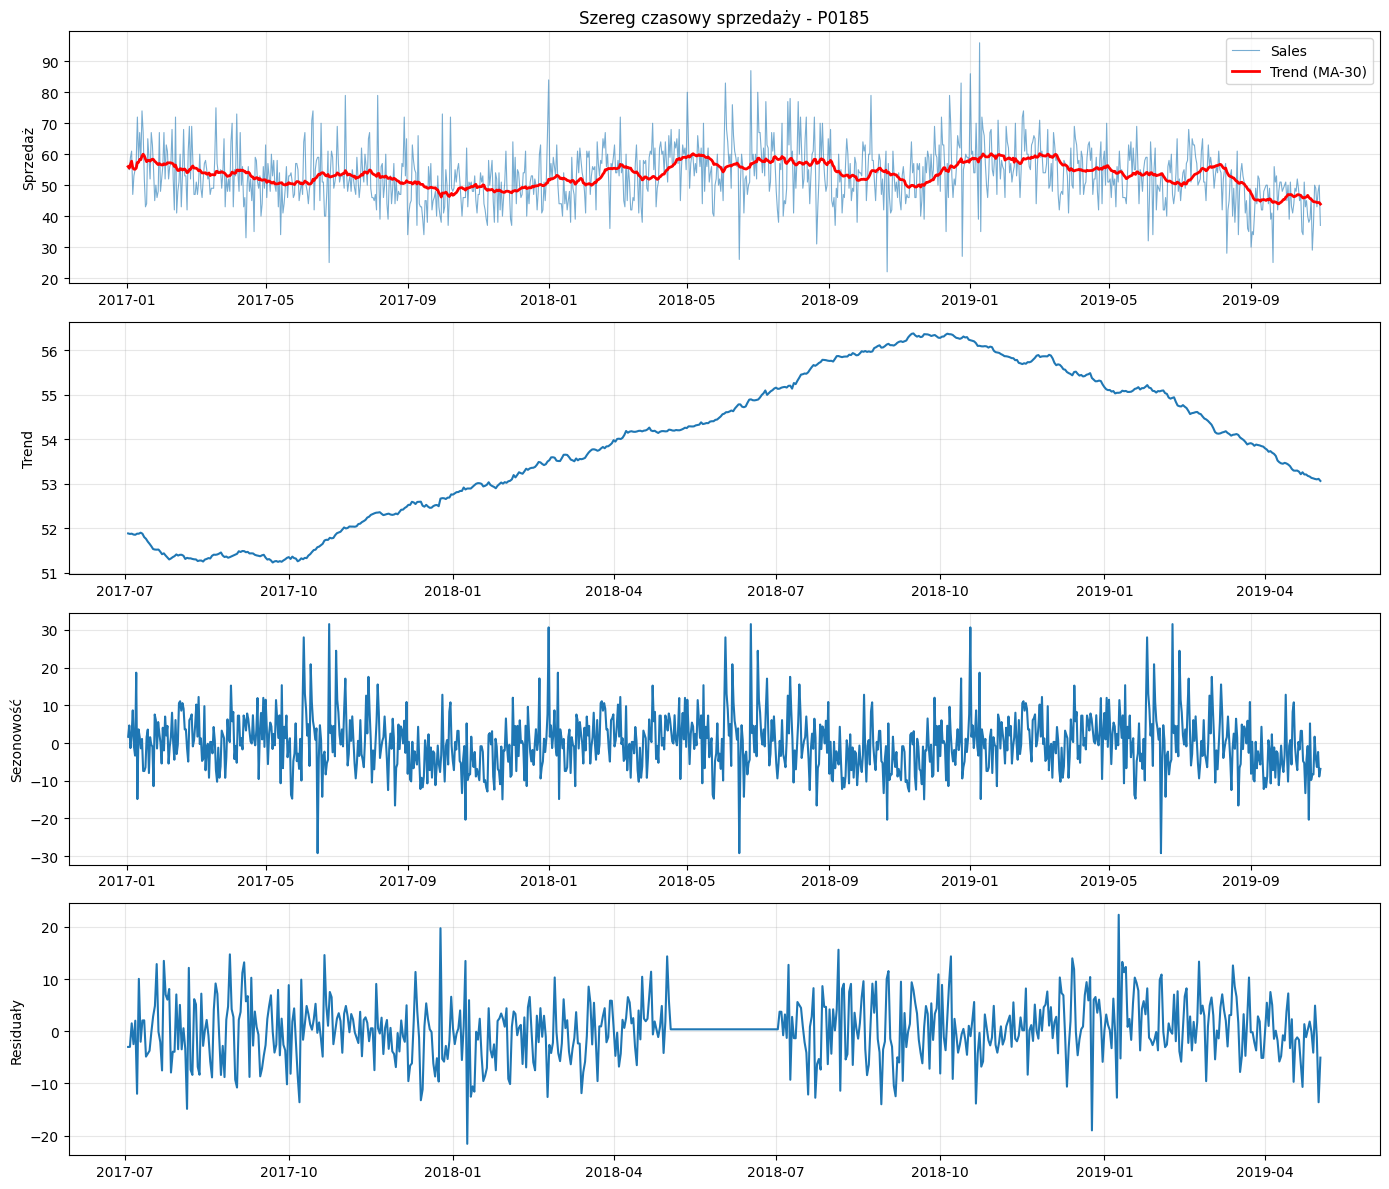

In [3]:
ts = df_agg[['date', 'sales', 'price']].set_index('date')

print(f"\n1. DEKOMPOZYCJA SZEREGU CZASOWEGO")
print(f"   Długość okresu: {len(ts)} dni ({len(ts)/365:.1f} lat)")

try:
    decomposition = seasonal_decompose(ts['sales'], model='additive', period=365)
    trend_std = decomposition.trend.std()
    seasonal_std = decomposition.seasonal.std()
    residual_std = decomposition.resid.std()
    
    seasonal_strength = 1 - (residual_std**2 / (seasonal_std + residual_std)**2)
    trend_strength = 1 - (residual_std**2 / (trend_std + residual_std)**2)
    
    print(f"   Siła trendu: {trend_strength:.4f}")
    print(f"   Siła sezonowości: {seasonal_strength:.4f}")
except Exception as e:
    print(f"   Dekompozycja nie powiodła się: {e}")
    decomposition = None

print(f"\n2. SEZONOWOŚĆ - DNI TYGODNIA")
dow_stats = df_agg.groupby('day_of_week')['sales'].agg(['mean', 'std', 'count'])
dow_names = ['Pon', 'Wto', 'Śro', 'Czw', 'Pią', 'Sob', 'Nie']
dow_stats.index = dow_names
print(dow_stats.round(2))

print(f"\n3. SEZONOWOŚĆ - MIESIĄCE")
month_stats = df_agg.groupby('month')['sales'].agg(['mean', 'std'])
print(month_stats.round(2))

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df_agg['date'], df_agg['sales'], label='Sales', alpha=0.6, linewidth=0.8)
axes[0].plot(df_agg['date'], df_agg['sales_ma_30d'], label='Trend (MA-30)', color='red', linewidth=2)
axes[0].set_ylabel('Sprzedaż')
axes[0].set_title(f'Szereg czasowy sprzedaży - {top_product}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if decomposition is not None:
    axes[1].plot(decomposition.trend.index, decomposition.trend)
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal)
    axes[2].set_ylabel('Sezonowość')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(decomposition.resid.index, decomposition.resid)
    axes[3].set_ylabel('Residuały')
    axes[3].grid(True, alpha=0.3)
else:
    dow_avg = df_agg.groupby('day_of_week')['sales'].mean()
    axes[1].bar(range(7), dow_avg.values, color='skyblue')
    axes[1].set_xticks(range(7))
    axes[1].set_xticklabels(dow_names)
    axes[1].set_ylabel('Średnia sprzedaż')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    month_avg = df_agg.groupby('month')['sales'].mean()
    axes[2].plot(month_avg.index, month_avg.values, marker='o', linewidth=2)
    axes[2].set_ylabel('Średnia sprzedaż')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].scatter(df_agg['price'], df_agg['sales'], alpha=0.3, s=10)
    axes[3].set_xlabel('Cena')
    axes[3].set_ylabel('Sprzedaż')
    axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trend_seasonality_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

### Przygotowanie Danych do Modelu

**Cel:** Przekształcić dane w format dla ML.

**Kroki:**
1. Normalizacja MinMax (0-1)
2. Tworzenie sekwencji (lookback=14 dni)
3. Podział train/test (80/20)

In [4]:
from sklearn.preprocessing import MinMaxScaler

print(f"\n  PRZYGOTOWANIE CECH")
feature_cols = ['sales', 'price', 'day_of_week', 'month', 'week_of_year', 
                'is_weekend', 'trend', 'sales_ma_7d', 'price_ratio']

X_data = df_agg[feature_cols].copy()
y_data = df_agg['sales'].copy()
print(f"   Cechy: {len(feature_cols)} zmiennych, Próbki: {len(X_data)}")

print(f"\n  NORMALIZACJA")
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data.values.reshape(-1, 1)).flatten()

print(f"\n  TWORZENIE SEKWENCJI (Lookback=14)")
def create_sequences(X, y, lookback=14):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i+lookback, :])
        y_seq.append(y[i+lookback])
    return np.array(X_seq), np.array(y_seq)

lookback = 14
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback=lookback)
print(f"   Kształt X_seq: {X_seq.shape}, y_seq: {y_seq.shape}")

print(f"\n  PODZIAŁ TRAIN/TEST")
train_size = int(len(X_seq) * 0.8)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_test, y_test = X_seq[train_size:], y_seq[train_size:]
print(f"   Train: {len(X_train)}, Test: {len(X_test)}")


  PRZYGOTOWANIE CECH
   Cechy: 9 zmiennych, Próbki: 1033

  NORMALIZACJA

  TWORZENIE SEKWENCJI (Lookback=14)
   Kształt X_seq: (1019, 14, 9), y_seq: (1019,)

  PODZIAŁ TRAIN/TEST
   Train: 815, Test: 204


### Skanowanie Produktów

**Cel:** Wybrać produkt najlepszy do modelowania dynamic pricing.

**Metryki oceny:**
- **CV (zmienność)** - std/mean, ideał: 0.3-0.5
- **Korelacja cena-sprzedaż** - czy cena wpływa na popyt
- **Sezonowość** - czy są powtarzające się wzorce

**Score = 2×CV + |korelacja| + 0.5×sezonowość**

In [5]:
df_all = pd.read_csv('sales.csv')
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all[df_all['sales'] > 0].copy()
df_all_agg = df_all.groupby(['date', 'product_id']).agg({
    'sales': 'sum', 'price': 'mean', 'revenue': 'sum'
}).reset_index()

print(f"\nDostępnych produktów: {df_all_agg['product_id'].nunique()}")

results = []
for product in df_all_agg['product_id'].unique()[:100]:
    df_prod = df_all_agg[df_all_agg['product_id'] == product].copy()
    if len(df_prod) < 100:
        continue
    
    sales_mean, sales_std = df_prod['sales'].mean(), df_prod['sales'].std()
    cv = sales_std / sales_mean if sales_mean > 0 else 0
    corr = df_prod['price'].corr(df_prod['sales'])
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(range(len(df_prod)), df_prod['sales'])
    trend_r2 = r_value ** 2
    
    try:
        seasonality_var = (df_prod['sales'].iloc[:7].std() + df_prod['sales'].iloc[-7:].std()) / 2
    except:
        seasonality_var = 0
    
    results.append({
        'product': product, 'days': len(df_prod), 'sales_mean': sales_mean,
        'cv': cv, 'price_corr': corr, 'trend_r2': trend_r2, 'seasonality_var': seasonality_var
    })

results_df = pd.DataFrame(results)
results_df['score'] = results_df['cv'] * 2 + abs(results_df['price_corr']) + results_df['seasonality_var'] * 0.5
results_df = results_df.sort_values('score', ascending=False)

print(f"\nTop 10 produktów do modelowania:")
print(results_df[['product', 'days', 'sales_mean', 'cv', 'price_corr', 'score']].head(10).to_string(index=False))

best_product = results_df.iloc[0]['product']
print(f"\n Wybrany produkt: {best_product} (Score: {results_df.iloc[0]['score']:.3f})")


Dostępnych produktów: 629

Top 10 produktów do modelowania:
product  days  sales_mean       cv  price_corr     score
  P0103  1033  853.469506 2.246911   -0.090985 50.910593
  P0051  1033  229.181026 0.536694   -0.118315 18.645370
  P0282   593   14.812816 1.975217   -0.335157 17.639695
  P0131  1033  208.058083 0.505366    0.585617 17.555019
  P0017  1033  100.744434 0.631716   -0.550925 15.589996
  P0129  1033   56.957406 3.750812   -0.026834 15.098770
  P0261  1033  142.264279 0.853639   -0.111315 13.017875
  P0116  1033   83.353340 0.370921   -0.125434 11.748193
  P0198  1025   84.555122 0.547788   -0.462027 11.682791
  P0140  1033   35.973863 0.650424   -0.295830  9.260127

 Wybrany produkt: P0103 (Score: 50.911)


### Kompleksowa inżynieria cech

In [6]:
try:
    import xgboost as xgb
    import lightgbm as lgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost", "lightgbm"])
    import xgboost as xgb
    import lightgbm as lgb

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
print(f"XGBoost {xgb.__version__}, LightGBM {lgb.__version__}")

df_best = df_all_agg[df_all_agg['product_id'] == best_product].copy()
df_best = df_best.sort_values('date').reset_index(drop=True)
print(f"\nDane dla produktu {best_product}: {len(df_best)} dni")

print(f"\nFEATURE ENGINEERING")
lags = [1, 2, 3, 7, 14, 30, 365]
for lag in lags:
    df_best[f'sales_lag_{lag}'] = df_best['sales'].shift(lag)
    df_best[f'price_lag_{lag}'] = df_best['price'].shift(lag)

windows = [7, 14, 30]
for window in windows:
    df_best[f'sales_rolling_mean_{window}'] = df_best['sales'].rolling(window=window, min_periods=1).mean()
    df_best[f'sales_rolling_std_{window}'] = df_best['sales'].rolling(window=window, min_periods=1).std()
    df_best[f'price_rolling_mean_{window}'] = df_best['price'].rolling(window=window, min_periods=1).mean()
    df_best[f'price_rolling_min_{window}'] = df_best['price'].rolling(window=window, min_periods=1).min()
    df_best[f'price_rolling_max_{window}'] = df_best['price'].rolling(window=window, min_periods=1).max()

df_best['day_of_week'] = df_best['date'].dt.dayofweek
df_best['day_of_week_sin'] = np.sin(2 * np.pi * df_best['day_of_week'] / 7)
df_best['day_of_week_cos'] = np.cos(2 * np.pi * df_best['day_of_week'] / 7)
df_best['day_of_month'] = df_best['date'].dt.day
df_best['day_of_month_sin'] = np.sin(2 * np.pi * df_best['day_of_month'] / 31)
df_best['day_of_month_cos'] = np.cos(2 * np.pi * df_best['day_of_month'] / 31)
df_best['month'] = df_best['date'].dt.month
df_best['month_sin'] = np.sin(2 * np.pi * df_best['month'] / 12)
df_best['month_cos'] = np.cos(2 * np.pi * df_best['month'] / 12)
df_best['day_of_year'] = df_best['date'].dt.dayofyear
df_best['day_of_year_sin'] = np.sin(2 * np.pi * df_best['day_of_year'] / 365)
df_best['day_of_year_cos'] = np.cos(2 * np.pi * df_best['day_of_year'] / 365)
df_best['week_of_year'] = df_best['date'].dt.isocalendar().week

df_best['is_weekend'] = (df_best['day_of_week'] >= 5).astype(int)
df_best['is_monday'] = (df_best['day_of_week'] == 0).astype(int)
df_best['is_friday'] = (df_best['day_of_week'] == 4).astype(int)

df_best['trend'] = np.arange(len(df_best))
df_best['trend_squared'] = df_best['trend'] ** 2

df_best['price_ratio'] = df_best['price'] / (df_best['price_rolling_mean_30'] + 1e-6)
df_best['price_change'] = df_best['price'].diff()
df_best['price_pct_change'] = df_best['price'].pct_change()

df_best['sales_diff'] = df_best['sales'].diff()
df_best['sales_diff_7'] = df_best['sales'].diff(7)

df_best = df_best.dropna()
print(f"  Liczba cech: {len([col for col in df_best.columns if col not in ['date', 'product_id', 'sales', 'price', 'revenue']])}")
print(f"  Wierszy: {len(df_best)}")

XGBoost 3.1.3, LightGBM 4.6.0

Dane dla produktu P0103: 1033 dni

FEATURE ENGINEERING
  Liczba cech: 52
  Wierszy: 668


### Trening modeli - XGBOOST + LIGHTBGM

In [7]:
feature_cols = [col for col in df_best.columns if col not in ['date', 'product_id', 'sales', 'price', 'revenue']]
X = df_best[feature_cols].copy()
y = df_best['sales'].copy()
print(f"\n  DANE: {X.shape[1]} cech, {X.shape[0]} próbek")

train_size = int(len(X) * 0.8)
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
print(f"   Train: {len(X_train)}, Test: {len(X_test)}")

print(f"\n  XGBOOST")
xgb_model = XGBRegressor(
    n_estimators=300, max_depth=7, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, objective='reg:absoluteerror', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / (y_test + 1e-6))) * 100
print(f"   MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}, MAPE: {mape_xgb:.2f}%")

print(f"\n  LIGHTGBM + OPTUNA")
import optuna
from optuna.samplers import TPESampler

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'mae', 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    return mean_absolute_error(y_test, model.predict(X_test))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"   Best MAE: {study.best_value:.2f}")
lgb_model = LGBMRegressor(**study.best_params, objective='mae', random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test - y_pred_lgb) / (y_test + 1e-6))) * 100
print(f"   MAE: {mae_lgb:.2f}, RMSE: {rmse_lgb:.2f}, R²: {r2_lgb:.4f}, MAPE: {mape_lgb:.2f}%")

print(f"\n4. PORÓWNANIE Z BASELINE")
baseline_pred = np.ones_like(y_test) * y_train.mean()
mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)
print(f"   Baseline MAE: {mae_baseline:.2f}, R²: {r2_baseline:.4f}")
print(f"   XGBoost poprawa: {100*(mae_baseline-mae_xgb)/mae_baseline:.1f}%")
print(f"   LightGBM poprawa: {100*(mae_baseline-mae_lgb)/mae_baseline:.1f}%")

if r2_xgb > r2_lgb:
    best_model, y_pred_best, r2_best, mae_best, model_name = xgb_model, y_pred_xgb, r2_xgb, mae_xgb, "XGBoost"
else:
    best_model, y_pred_best, r2_best, mae_best, model_name = lgb_model, y_pred_lgb, r2_lgb, mae_lgb, "LightGBM"
print(f"\n  Najlepszy: {model_name} (R²={r2_best:.4f})")

import pickle
with open('xgboost_model.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('lightgbm_model.pkl', 'wb') as f: pickle.dump(lgb_model, f)


  DANE: 52 cech, 668 próbek
   Train: 534, Test: 134

  XGBOOST
   MAE: 29.03, RMSE: 50.93, R²: 0.9331, MAPE: 3.36%

  LIGHTGBM + OPTUNA


Best trial: 31. Best value: 20.6767: 100%|██████████| 50/50 [00:11<00:00,  4.26it/s]


   Best MAE: 20.68
   MAE: 20.68, RMSE: 42.72, R²: 0.9529, MAPE: 2.37%

4. PORÓWNANIE Z BASELINE
   Baseline MAE: 174.37, R²: -0.3780
   XGBoost poprawa: 83.4%
   LightGBM poprawa: 88.1%

  Najlepszy: LightGBM (R²=0.9529)


### LSTM PRO - Optuna + Ensemble

**Ulepszenia:** Optuna tuning (50 prób), ensemble 3 modeli, data augmentation, rozszerzone cechy (lagi, momentum)

LSTM PRO - HYPERPARAMETER TUNING + ENSEMBLE
   Liczba cech: 34

2. DATA AUGMENTATION

3. PRZYGOTOWANIE SEKWENCJI
   Lookback: 28 dni
   Wymiary: (550, 28, 34)
   Train (po augmentacji): 1155 (z 385)
   Val: 82, Test: 83

 OPTUNA HYPERPARAMETER TUNING
   Szukanie optymalnych hiperparametrów (50 prób)...


  0%|          | 0/50 [00:00<?, ?it/s]2026-01-30 20:58:45.416561: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-01-30 20:58:46.553811: I external/local_xla/xla/service/service.cc:168] XLA service 0x7be57cfaacf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 20:58:46.553856: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-01-30 20:58:46.589513: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769803126.685961   17260 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Best trial: 3. Best value: 0.399562:   8%|▊         | 4/50 [01:40<19:15, 25.12s/it]

Best trial: 3. Best value: 0.399562:  10%|█         | 5/50 [03:42<44:56, 59.91s/it]

Best trial: 49. Best value: 0.339799: 100%|██████████| 50/50 [49:44<00:00, 59.68s/it] 



   Najlepsza wartość MAE (val): 0.3398

   Najlepsze hiperparametry:
      n_layers: 3
      units_1: 64
      units_2: 32
      units_3: 16
      dropout_rate: 0.10283643234132643
      l2_reg: 0.00012549283118439792
      learning_rate: 0.003724076467792356
      use_bidirectional: True
      use_gru: True
      batch_size: 8

5. TRENING NAJLEPSZEGO MODELU
Epoch 1/300
145/145 [==============================] - 8s 32ms/step - loss: 0.1580 - mae: 0.3672 - val_loss: 0.2028 - val_mae: 0.4700 - lr: 0.0037
Epoch 2/300
145/145 [==============================] - 4s 29ms/step - loss: 0.1272 - mae: 0.3134 - val_loss: 0.2016 - val_mae: 0.4457 - lr: 0.0037
Epoch 3/300
145/145 [==============================] - 4s 28ms/step - loss: 0.1166 - mae: 0.2859 - val_loss: 0.2137 - val_mae: 0.4478 - lr: 0.0037
Epoch 4/300
145/145 [==============================] - 4s 29ms/step - loss: 0.1086 - mae: 0.2782 - val_loss: 0.1924 - val_mae: 0.4411 - lr: 0.0037
Epoch 5/300
145/145 [=============================

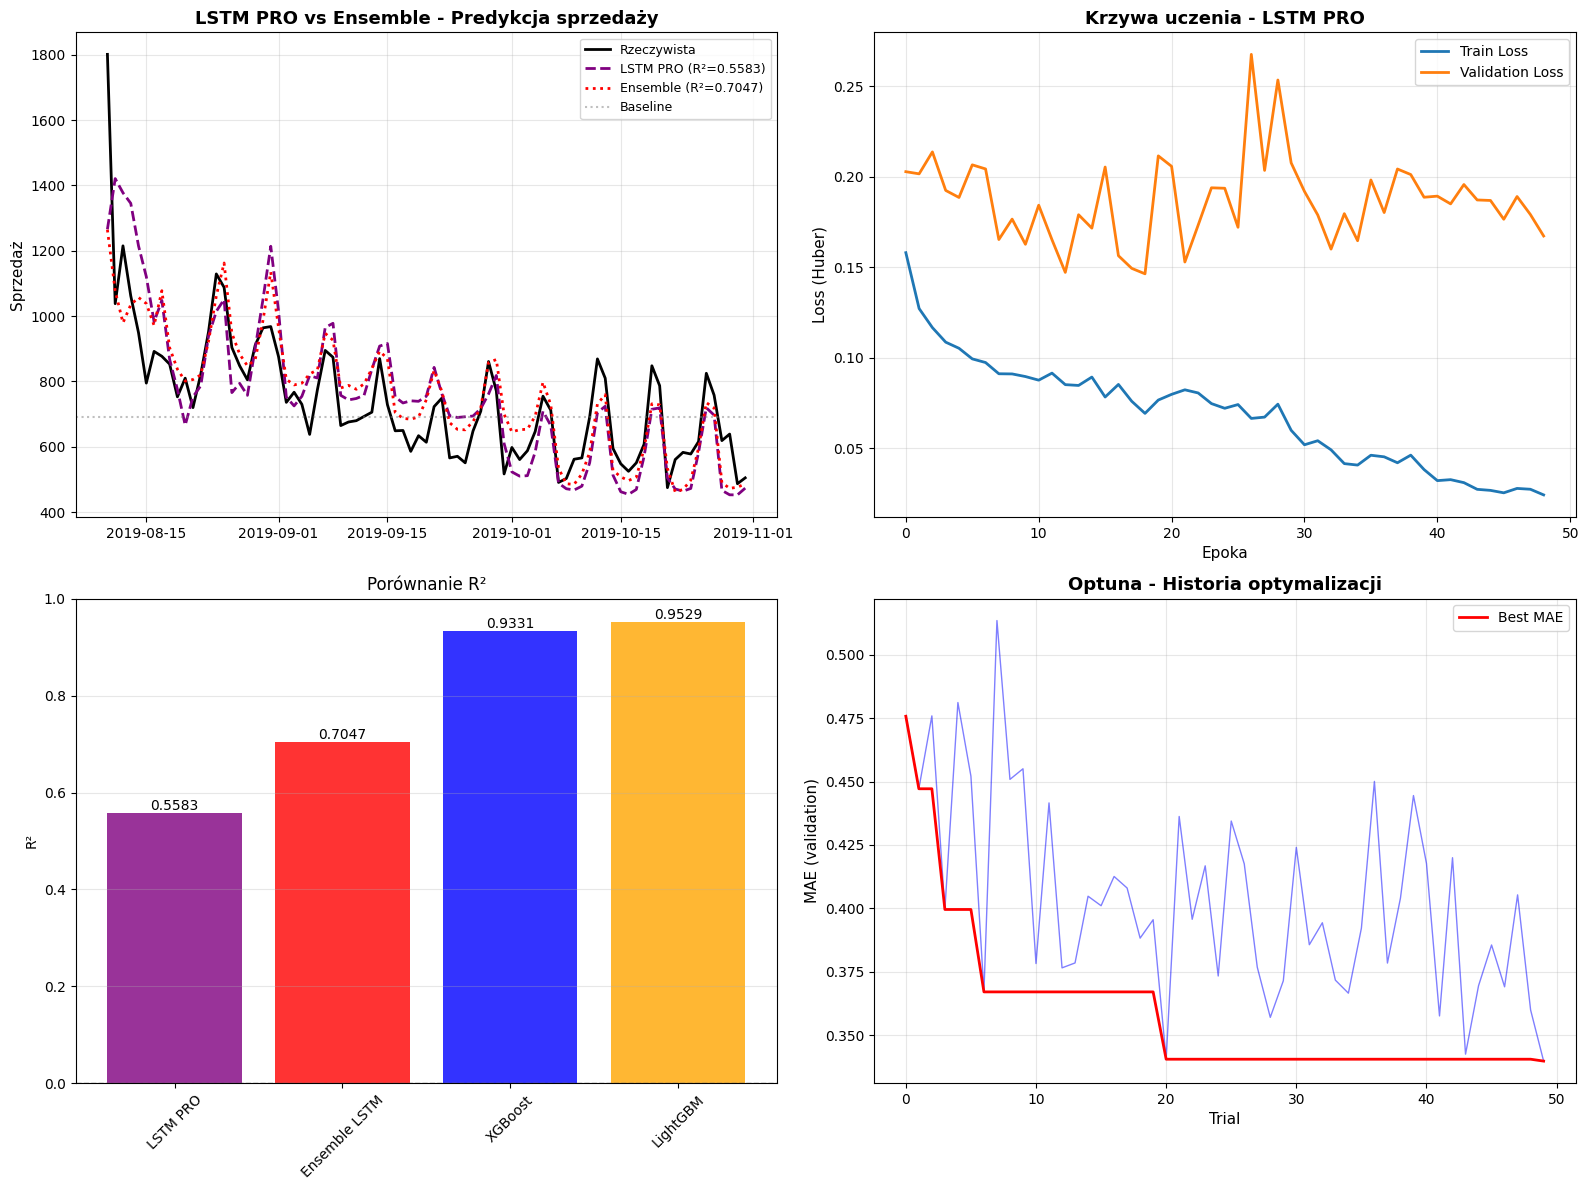


PODSUMOWANIE

        Model        MAE        R²  MAPE (%)
     LightGBM  20.676707  0.952929  2.373174
      XGBoost  29.029201  0.933097  3.359351
Ensemble LSTM  80.178983  0.704723 10.804320
     LSTM PRO 100.533001  0.558260 13.248126
     Baseline 144.808387 -0.069267 18.379238

 NAJLEPSZY MODEL: LightGBM
  • R²: 0.9529
  • MAE: 20.68
  • MAPE: 2.37%

 Model zapisany: lstm_pro_final.keras


In [8]:
print("LSTM PRO - HYPERPARAMETER TUNING + ENSEMBLE")

K.clear_session()
gc.collect()

extended_lags = [1, 2, 3, 5, 7, 10, 14, 21, 28, 30, 60, 90, 365]
for lag in extended_lags:
    col_name = f'sales_lag_{lag}'
    if col_name not in df_best.columns:
        df_best[col_name] = df_best['sales'].shift(lag)

extended_windows = [3, 5, 7, 14, 21, 30, 60]
for window in extended_windows:
    mean_col = f'sales_rolling_mean_{window}'
    std_col = f'sales_rolling_std_{window}'
    if mean_col not in df_best.columns:
        df_best[mean_col] = df_best['sales'].rolling(window=window, min_periods=1).mean()
    if std_col not in df_best.columns:
        df_best[std_col] = df_best['sales'].rolling(window=window, min_periods=1).std()

df_best['sales_momentum_7'] = df_best['sales'] - df_best['sales'].shift(7)
df_best['sales_momentum_30'] = df_best['sales'] - df_best['sales'].shift(30)
df_best['sales_pct_change_7'] = df_best['sales'].pct_change(7)
df_best['sales_pct_change_30'] = df_best['sales'].pct_change(30)

# Usuń NaN
df_best_pro = df_best.dropna().copy()

# Rozszerzona lista cech
lstm_features_pro = [
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_5', 
    'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_30',
    'sales_rolling_mean_3', 'sales_rolling_mean_5', 'sales_rolling_mean_7', 
    'sales_rolling_mean_14', 'sales_rolling_mean_21', 'sales_rolling_mean_30',
    'sales_rolling_std_7', 'sales_rolling_std_14', 'sales_rolling_std_30',
    'sales_momentum_7', 'sales_momentum_30',
    'sales_pct_change_7', 'sales_pct_change_30',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos',
    'day_of_year_sin', 'day_of_year_cos',
    'is_weekend', 'is_monday', 'is_friday',
    'trend',
    'price', 'price_ratio', 'price_rolling_mean_30'
]

available_features_pro = [f for f in lstm_features_pro if f in df_best_pro.columns]
print(f"   Liczba cech: {len(available_features_pro)}")

# Przygotuj dane
X_pro = df_best_pro[available_features_pro].values
y_pro = df_best_pro['sales'].values

# Skalowanie
scaler_X_pro = RobustScaler()
scaler_y_pro = RobustScaler()
X_scaled_pro = scaler_X_pro.fit_transform(X_pro)
y_scaled_pro = scaler_y_pro.fit_transform(y_pro.reshape(-1, 1))

print("\n2. DATA AUGMENTATION")

def augment_data(X, y, noise_level=0.02, n_augments=2):
    """Dodaje szum do danych treningowych dla lepszej generalizacji"""
    X_aug = [X]
    y_aug = [y]
    
    for _ in range(n_augments):
        noise = np.random.normal(0, noise_level, X.shape)
        X_noisy = X + noise
        X_aug.append(X_noisy)
        y_aug.append(y)
    
    return np.vstack(X_aug), np.vstack(y_aug)

# Przygotowanie sekwencji z różnymi lookback
print("\n3. PRZYGOTOWANIE SEKWENCJI")

lookback_pro = 28  # 4 tygodnie

X_seq_pro, y_seq_pro = create_sequences(X_scaled_pro, y_scaled_pro, lookback_pro)

print(f"   Lookback: {lookback_pro} dni")
print(f"   Wymiary: {X_seq_pro.shape}")

# Podział danych
n_samples_pro = len(X_seq_pro)
train_end_pro = int(n_samples_pro * 0.70)
val_end_pro = int(n_samples_pro * 0.85)

X_train_pro = X_seq_pro[:train_end_pro]
y_train_pro = y_seq_pro[:train_end_pro]
X_val_pro = X_seq_pro[train_end_pro:val_end_pro]
y_val_pro = y_seq_pro[train_end_pro:val_end_pro]
X_test_pro = X_seq_pro[val_end_pro:]
y_test_pro = y_seq_pro[val_end_pro:]

# Augmentacja danych treningowych
X_train_aug, y_train_aug = augment_data(X_train_pro, y_train_pro, noise_level=0.01, n_augments=2)
print(f"   Train (po augmentacji): {len(X_train_aug)} (z {len(X_train_pro)})")
print(f"   Val: {len(X_val_pro)}, Test: {len(X_test_pro)}")

print("\n OPTUNA HYPERPARAMETER TUNING")
print("   Szukanie optymalnych hiperparametrów (50 prób)...")

def create_model_optuna(trial, input_shape):
    """Tworzy model z hiperparametrami z Optuna"""
    K.clear_session()
    
    # Hiperparametry
    n_layers = trial.suggest_int('n_layers', 2, 4)
    units_1 = trial.suggest_categorical('units_1', [64, 96, 128, 192])
    units_2 = trial.suggest_categorical('units_2', [32, 48, 64, 96])
    units_3 = trial.suggest_categorical('units_3', [16, 32, 48])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    use_bidirectional = trial.suggest_categorical('use_bidirectional', [True, False])
    use_gru = trial.suggest_categorical('use_gru', [True, False])
    
    # Wybór typu warstwy RNN
    RNN_Layer = GRU if use_gru else LSTM
    
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    if use_bidirectional:
        model.add(Bidirectional(RNN_Layer(units_1, return_sequences=True,
                                          kernel_regularizer=l2(l2_reg))))
    else:
        model.add(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(RNN_Layer(units_2, return_sequences=(n_layers > 2), kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    if n_layers >= 3:
        model.add(RNN_Layer(units_3, return_sequences=(n_layers > 3), kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate * 0.5))
    
    if n_layers >= 4:
        model.add(RNN_Layer(16, return_sequences=False))
        model.add(Dropout(dropout_rate * 0.5))
    
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='huber',
        metrics=['mae']
    )
    
    return model

def objective(trial):
    """Funkcja celu dla Optuna"""
    try:
        model = create_model_optuna(trial, (X_train_pro.shape[1], X_train_pro.shape[2]))
        
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
        
        model.fit(
            X_train_aug, y_train_aug,
            epochs=50,
            batch_size=trial.suggest_categorical('batch_size', [8, 16, 32]),
            validation_data=(X_val_pro, y_val_pro),
            callbacks=[early_stop],
            verbose=0
        )
        
        y_pred_val = model.predict(X_val_pro, verbose=0)
        mae = mean_absolute_error(y_val_pro, y_pred_val)
        
        del model
        K.clear_session()
        gc.collect()
        
        return mae
    except Exception as e:
        return float('inf')

# Optymalizacja
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lstm = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lstm.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n   Najlepsza wartość MAE (val): {study_lstm.best_value:.4f}")
print(f"\n   Najlepsze hiperparametry:")
for key, value in study_lstm.best_params.items():
    print(f"      {key}: {value}")

print("\n5. TRENING NAJLEPSZEGO MODELU")

K.clear_session()

# Pobierz najlepsze parametry
best_params = study_lstm.best_params

# Utwórz model z najlepszymi parametrami
def build_best_model(params, input_shape):
    K.clear_session()
    
    n_layers = params['n_layers']
    units_1 = params['units_1']
    units_2 = params['units_2']
    units_3 = params['units_3']
    dropout_rate = params['dropout_rate']
    l2_reg = params['l2_reg']
    learning_rate = params['learning_rate']
    use_bidirectional = params['use_bidirectional']
    use_gru = params['use_gru']
    
    RNN_Layer = GRU if use_gru else LSTM
    
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    if use_bidirectional:
        model.add(Bidirectional(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))))
    else:
        model.add(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(RNN_Layer(units_2, return_sequences=(n_layers > 2), kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    if n_layers >= 3:
        model.add(RNN_Layer(units_3, return_sequences=(n_layers > 3), kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate * 0.5))
    
    if n_layers >= 4:
        model.add(RNN_Layer(16, return_sequences=False))
        model.add(Dropout(dropout_rate * 0.5))
    
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='huber', metrics=['mae'])
    return model

lstm_pro_model = build_best_model(best_params, (X_train_pro.shape[1], X_train_pro.shape[2]))

early_stop_pro = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
reduce_lr_pro = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
checkpoint_pro = ModelCheckpoint('best_model_lstm_pro.keras', monitor='val_loss', save_best_only=True, verbose=0)

history_pro = lstm_pro_model.fit(
    X_train_aug, y_train_aug,
    epochs=300,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_pro, y_val_pro),
    callbacks=[early_stop_pro, reduce_lr_pro, checkpoint_pro],
    verbose=1
)

print(f"\n   Trening zakończony po {len(history_pro.history['loss'])} epokach")

print("\n6. ENSEMBLE - TRENOWANIE MODELI")

n_ensemble = 3
ensemble_models = []
ensemble_predictions = []

for i in range(n_ensemble):
    print(f"\n   Model {i+1}/{n_ensemble}...")
    
    # Różne seedy dla różnorodności
    np.random.seed(42 + i)
    tf.random.set_seed(42 + i)
    
    model_i = build_best_model(best_params, (X_train_pro.shape[1], X_train_pro.shape[2]))
    
    early_stop_i = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    
    model_i.fit(
        X_train_aug, y_train_aug,
        epochs=150,
        batch_size=best_params['batch_size'],
        validation_data=(X_val_pro, y_val_pro),
        callbacks=[early_stop_i],
        verbose=0
    )
    
    pred_i = model_i.predict(X_test_pro, verbose=0)
    ensemble_predictions.append(pred_i)
    ensemble_models.append(model_i)
    
    mae_i = mean_absolute_error(y_test_pro, pred_i)
    print(f"      MAE (scaled): {mae_i:.4f}")

# Średnia predykcji ensemble
y_pred_ensemble_pro_scaled = np.mean(ensemble_predictions, axis=0)

print("\n7. EWALUACJA")

# Załaduj najlepszy pojedynczy model
lstm_pro_model = load_model('best_model_lstm_pro.keras')

# Predykcje pojedynczego modelu
y_pred_pro_scaled = lstm_pro_model.predict(X_test_pro, verbose=0)
y_pred_pro = scaler_y_pro.inverse_transform(y_pred_pro_scaled)
y_test_pro_original = scaler_y_pro.inverse_transform(y_test_pro)

# Predykcje ensemble
y_pred_ensemble_pro = scaler_y_pro.inverse_transform(y_pred_ensemble_pro_scaled)

# Metryki - pojedynczy model
mae_lstm_pro = mean_absolute_error(y_test_pro_original, y_pred_pro)
rmse_lstm_pro = np.sqrt(mean_squared_error(y_test_pro_original, y_pred_pro))
r2_lstm_pro = r2_score(y_test_pro_original, y_pred_pro)
mape_lstm_pro = np.mean(np.abs((y_test_pro_original - y_pred_pro) / (y_test_pro_original + 1e-6))) * 100

# Metryki - ensemble
mae_ensemble_pro = mean_absolute_error(y_test_pro_original, y_pred_ensemble_pro)
rmse_ensemble_pro = np.sqrt(mean_squared_error(y_test_pro_original, y_pred_ensemble_pro))
r2_ensemble_pro = r2_score(y_test_pro_original, y_pred_ensemble_pro)
mape_ensemble_pro = np.mean(np.abs((y_test_pro_original - y_pred_ensemble_pro) / (y_test_pro_original + 1e-6))) * 100

# Baseline
baseline_pro = np.mean(scaler_y_pro.inverse_transform(y_train_pro))
baseline_pred_pro = np.ones_like(y_test_pro_original) * baseline_pro
mae_baseline_pro = mean_absolute_error(y_test_pro_original, baseline_pred_pro)
r2_baseline_pro = r2_score(y_test_pro_original, baseline_pred_pro)

print(f"\n   WYNIKI LSTM PRO (Optuna):")
print(f"   MAE:  {mae_lstm_pro:.2f}")
print(f"   RMSE: {rmse_lstm_pro:.2f}")
print(f"   R²:   {r2_lstm_pro:.4f}")
print(f"   MAPE: {mape_lstm_pro:.2f}%")

print(f"\n   WYNIKI ENSEMBLE ({n_ensemble} modeli):")
print(f"   MAE:  {mae_ensemble_pro:.2f}")
print(f"   RMSE: {rmse_ensemble_pro:.2f}")
print(f"   R²:   {r2_ensemble_pro:.4f}")
print(f"   MAPE: {mape_ensemble_pro:.2f}%")

print(f"\n   BASELINE:")
print(f"   MAE:  {mae_baseline_pro:.2f}")
print(f"   R²:   {r2_baseline_pro:.4f}")

# Poprawa vs baseline
improvement_single = 100 * (mae_baseline_pro - mae_lstm_pro) / mae_baseline_pro
improvement_ensemble = 100 * (mae_baseline_pro - mae_ensemble_pro) / mae_baseline_pro

print(f"\n   POPRAWA VS BASELINE:")
print(f"   LSTM PRO: {improvement_single:.1f}% (MAE)")
print(f"   Ensemble: {improvement_ensemble:.1f}% (MAE)")

print("\n8. WIZUALIZACJA")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daty testowe
test_dates_pro = df_best_pro['date'].iloc[lookback_pro + val_end_pro:].values

# Wykres 1: Predykcje vs Rzeczywistość
axes[0, 0].plot(test_dates_pro, y_test_pro_original.flatten(), 
                label='Rzeczywista', linewidth=2, color='black')
axes[0, 0].plot(test_dates_pro, y_pred_pro.flatten(), 
                label=f'LSTM PRO (R²={r2_lstm_pro:.4f})', linewidth=2, linestyle='--', color='purple')
axes[0, 0].plot(test_dates_pro, y_pred_ensemble_pro.flatten(), 
                label=f'Ensemble (R²={r2_ensemble_pro:.4f})', linewidth=2, linestyle=':', color='red')
axes[0, 0].axhline(y=baseline_pro, color='gray', linestyle=':', alpha=0.5, label='Baseline')
axes[0, 0].set_ylabel('Sprzedaż', fontsize=11)
axes[0, 0].set_title('LSTM PRO vs Ensemble - Predykcja sprzedaży', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Wykres 2: Krzywa uczenia
axes[0, 1].plot(history_pro.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history_pro.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoka', fontsize=11)
axes[0, 1].set_ylabel('Loss (Huber)', fontsize=11)
axes[0, 1].set_title('Krzywa uczenia - LSTM PRO', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

all_models = ['LSTM PRO', 'Ensemble LSTM', 'XGBoost', 'LightGBM']
all_r2 = [r2_lstm_pro, r2_ensemble_pro, r2_xgb, r2_lgb]
colors_all = ['purple', 'red', 'blue', 'orange']

bars = axes[1, 0].bar(all_models, all_r2, color=colors_all, alpha=0.8)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_title('Porównanie R²')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, all_r2):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.4f}', ha='center', va='bottom')

# Wykres 4: Optuna - historia optymalizacji
trial_values = [t.value for t in study_lstm.trials if t.value is not None and t.value < float('inf')]
axes[1, 1].plot(range(len(trial_values)), trial_values, 'b-', alpha=0.5, linewidth=1)
axes[1, 1].plot(range(len(trial_values)), 
                [min(trial_values[:i+1]) for i in range(len(trial_values))], 
                'r-', linewidth=2, label='Best MAE')
axes[1, 1].set_xlabel('Trial', fontsize=11)
axes[1, 1].set_ylabel('MAE (validation)', fontsize=11)
axes[1, 1].set_title('Optuna - Historia optymalizacji', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_pro_results.png', dpi=100, bbox_inches='tight')
print(f"\n   Wykres zapisany: lstm_pro_results.png")
plt.show()

print("\nPODSUMOWANIE")
print("="*50)

final_comparison = pd.DataFrame({
    'Model': ['LSTM PRO', 'Ensemble LSTM', 'XGBoost', 'LightGBM', 'Baseline'],
    'MAE': [mae_lstm_pro, mae_ensemble_pro, mae_xgb, mae_lgb, mae_baseline_pro],
    'R²': [r2_lstm_pro, r2_ensemble_pro, r2_xgb, r2_lgb, r2_baseline_pro],
    'MAPE (%)': [mape_lstm_pro, mape_ensemble_pro, mape_xgb, mape_lgb,
                 np.mean(np.abs((y_test_pro_original - baseline_pred_pro) / (y_test_pro_original + 1e-6))) * 100]
})

final_comparison = final_comparison.sort_values('R²', ascending=False)
print(f"\n{final_comparison.to_string(index=False)}")

# Najlepszy model
best_final = final_comparison.iloc[0]
print(f"\n NAJLEPSZY MODEL: {best_final['Model']}")
print(f"  • R²: {best_final['R²']:.4f}")
print(f"  • MAE: {best_final['MAE']:.2f}")
print(f"  • MAPE: {best_final['MAPE (%)']:.2f}%")

lstm_pro_model.save('lstm_pro_final.keras')
print(f"\n Model zapisany: lstm_pro_final.keras")

### Uczenie zespolone (ensemble learning)

In [9]:
from scipy.optimize import minimize

print("\n TWORZENIE ENSEMBLU XGB+LGB")

def ensemble_objective(weights):
    w = weights / np.sum(weights)
    y_pred_ensemble = w[0] * y_pred_xgb + w[1] * y_pred_lgb
    return mean_absolute_error(y_test, y_pred_ensemble)

initial_weights = np.array([0.5, 0.5])
bounds = [(0, 1), (0, 1)]
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

result = minimize(ensemble_objective, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x
print(f"   Wagi: XGBoost={optimal_weights[0]:.3f}, LightGBM={optimal_weights[1]:.3f}")

y_pred_ensemble = optimal_weights[0] * y_pred_xgb + optimal_weights[1] * y_pred_lgb

mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
r2_ensemble = r2_score(y_test, y_pred_ensemble)
mape_ensemble = np.mean(np.abs((y_test - y_pred_ensemble) / (y_test + 1e-6))) * 100

print(f"\n WYNIKI")
print(f"   {'Model':<12} {'MAE':>8} {'R²':>8} {'MAPE':>8}")
print(f"   {'XGBoost':<12} {mae_xgb:>8.2f} {r2_xgb:>8.4f} {mape_xgb:>7.2f}%")
print(f"   {'LightGBM':<12} {mae_lgb:>8.2f} {r2_lgb:>8.4f} {mape_lgb:>7.2f}%")
print(f"   {'ENSEMBLE':<12} {mae_ensemble:>8.2f} {r2_ensemble:>8.4f} {mape_ensemble:>7.2f}%")

best_single_mae = min(mae_xgb, mae_lgb)
mae_improvement = ((best_single_mae - mae_ensemble) / best_single_mae) * 100
print(f"\n   Poprawa MAE: {mae_improvement:+.2f}%")

best_model_type = "Ensemble"
y_pred_best = y_pred_ensemble
r2_best = r2_ensemble
mae_best = mae_ensemble
model_name = "Ensemble (XGB+LGB)"


 TWORZENIE ENSEMBLU XGB+LGB
   Wagi: XGBoost=0.498, LightGBM=0.502

 WYNIKI
   Model             MAE       R²     MAPE
   XGBoost         29.03   0.9331    3.36%
   LightGBM        20.68   0.9529    2.37%
   ENSEMBLE        22.72   0.9517    2.60%

   Poprawa MAE: -9.87%


### Wizualizacja wyników i analiza ważności cech

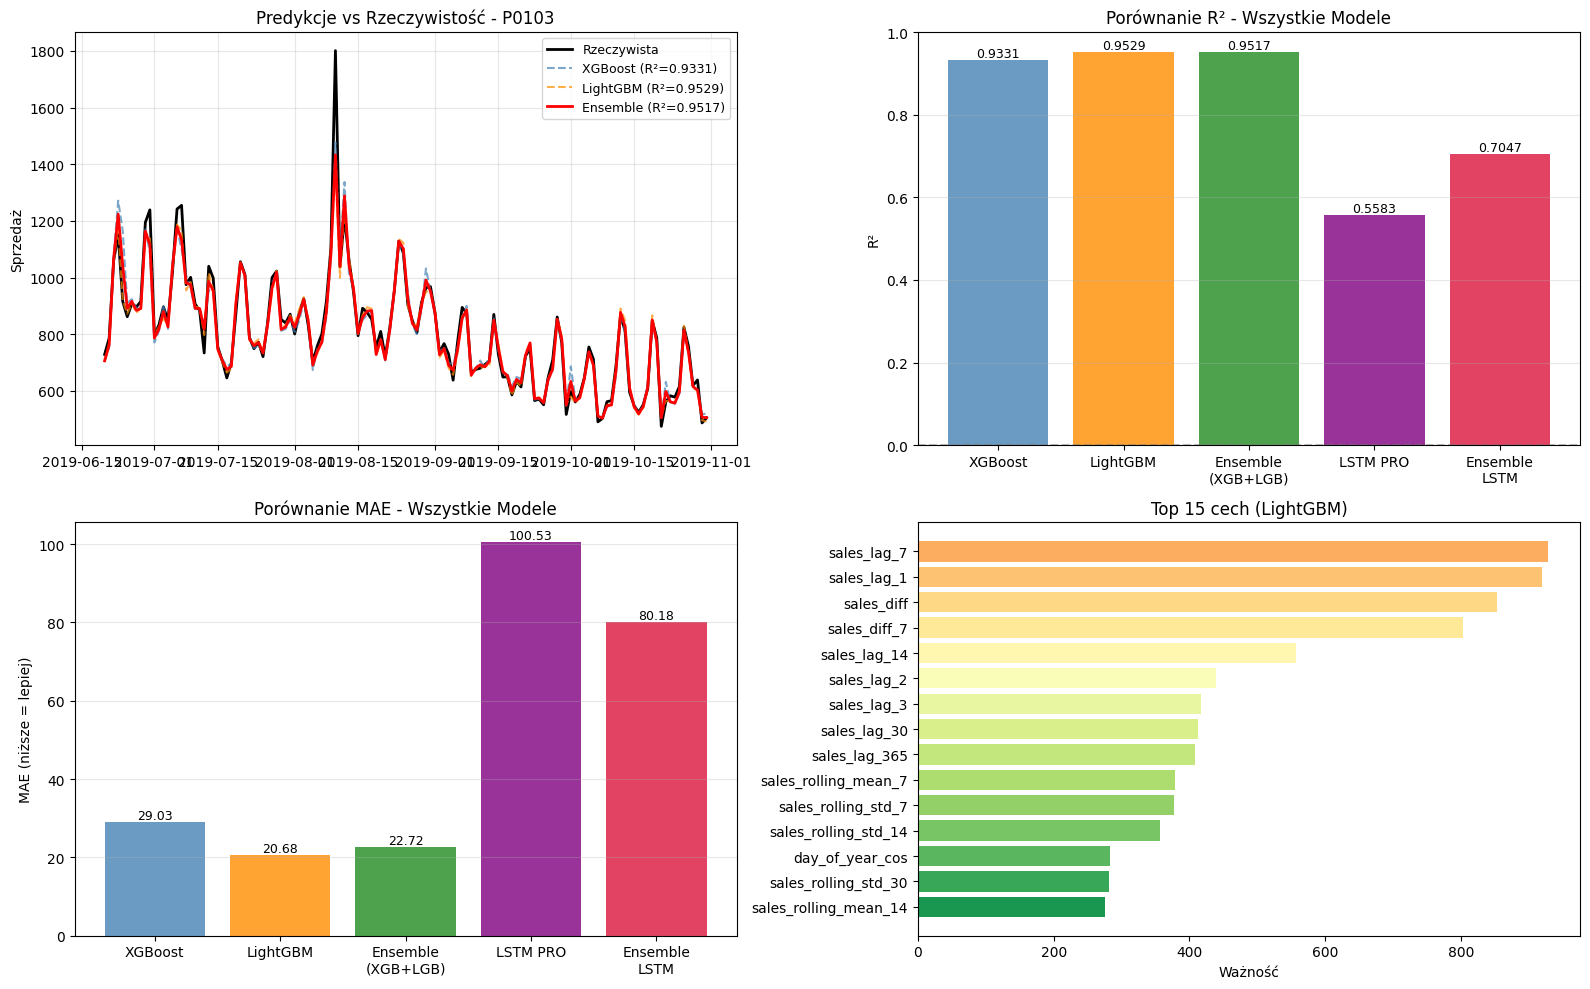

PODSUMOWANIE WSZYSTKICH MODELI
             Model        MAE       R²
          LightGBM  20.676707 0.952929
Ensemble (XGB+LGB)  22.717419 0.951742
           XGBoost  29.029201 0.933097
     Ensemble LSTM  80.178983 0.704723
          LSTM PRO 100.533001 0.558260

 NAJLEPSZY: LightGBM (R²=0.9529, MAE=20.68)


In [10]:
test_dates = df_best['date'].iloc[train_size:].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Predykcje vs Rzeczywistość (wszystkie modele)
axes[0, 0].plot(test_dates, y_test.values, label='Rzeczywista', linewidth=2, color='black')
axes[0, 0].plot(test_dates, y_pred_xgb, label=f'XGBoost (R²={r2_xgb:.4f})', linewidth=1.5, linestyle='--', alpha=0.7, color='steelblue')
axes[0, 0].plot(test_dates, y_pred_lgb, label=f'LightGBM (R²={r2_lgb:.4f})', linewidth=1.5, linestyle='--', alpha=0.7, color='darkorange')
axes[0, 0].plot(test_dates, y_pred_ensemble, label=f'Ensemble (R²={r2_ensemble:.4f})', linewidth=2, linestyle='-', color='red')
axes[0, 0].set_ylabel('Sprzedaż')
axes[0, 0].set_title(f'Predykcje vs Rzeczywistość - {best_product}')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Porównanie R² wszystkich modeli (w tym LSTM PRO)
all_models = ['XGBoost', 'LightGBM', 'Ensemble\n(XGB+LGB)', 'LSTM PRO', 'Ensemble\nLSTM']
all_r2 = [r2_xgb, r2_lgb, r2_ensemble, r2_lstm_pro, r2_ensemble_pro]
all_colors = ['steelblue', 'darkorange', 'forestgreen', 'purple', 'crimson']
bars = axes[0, 1].bar(all_models, all_r2, color=all_colors, alpha=0.8)
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_title('Porównanie R² - Wszystkie Modele')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, all_r2):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Panel 3: Porównanie MAE wszystkich modeli
all_mae = [mae_xgb, mae_lgb, mae_ensemble, mae_lstm_pro, mae_ensemble_pro]
bars2 = axes[1, 0].bar(all_models, all_mae, color=all_colors, alpha=0.8)
axes[1, 0].set_ylabel('MAE (niższe = lepiej)')
axes[1, 0].set_title('Porównanie MAE - Wszystkie Modele')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, all_mae):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Panel 4: Feature importance
feature_importance = lgb_model.feature_importances_
importance_df = pd.DataFrame({'feature': feature_cols, 'importance': feature_importance}).sort_values('importance', ascending=False)
top_15 = importance_df.head(15)
axes[1, 1].barh(range(len(top_15)), top_15['importance'].values, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15))))
axes[1, 1].set_yticks(range(len(top_15)))
axes[1, 1].set_yticklabels(top_15['feature'].values)
axes[1, 1].set_xlabel('Ważność')
axes[1, 1].set_title('Top 15 cech (LightGBM)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('model_results.png', dpi=100, bbox_inches='tight')
plt.show()

# Podsumowanie wszystkich modeli
print("PODSUMOWANIE WSZYSTKICH MODELI")
summary_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Ensemble (XGB+LGB)', 'LSTM PRO', 'Ensemble LSTM'],
    'MAE': [mae_xgb, mae_lgb, mae_ensemble, mae_lstm_pro, mae_ensemble_pro],
    'R²': [r2_xgb, r2_lgb, r2_ensemble, r2_lstm_pro, r2_ensemble_pro]
}).sort_values('R²', ascending=False)
print(summary_df.to_string(index=False))

best_overall = summary_df.iloc[0]
print(f"\n NAJLEPSZY: {best_overall['Model']} (R²={best_overall['R²']:.4f}, MAE={best_overall['MAE']:.2f})")

### Testowanie Odporności Modeli

**Cel:** Sprawdzić jak modele radzą sobie z zaszumionymi danymi.

**Testy:** Szum gaussowski (0-50%), outliers, brakujące wartości, wrażliwość grup cech.


1. TEST SZUMU GAUSSOWSKIEGO (Tree models + LSTM)

2. TEST OUTLIERS
   Tree-based models:
     XGBoost: MAE=33.13, R²=0.9138
     LightGBM: MAE=26.74, R²=0.9126
     Ensemble: MAE=26.74, R²=0.9126
     LSTM PRO: MAE=99.16, R²=0.5646

3. WIZUALIZACJA


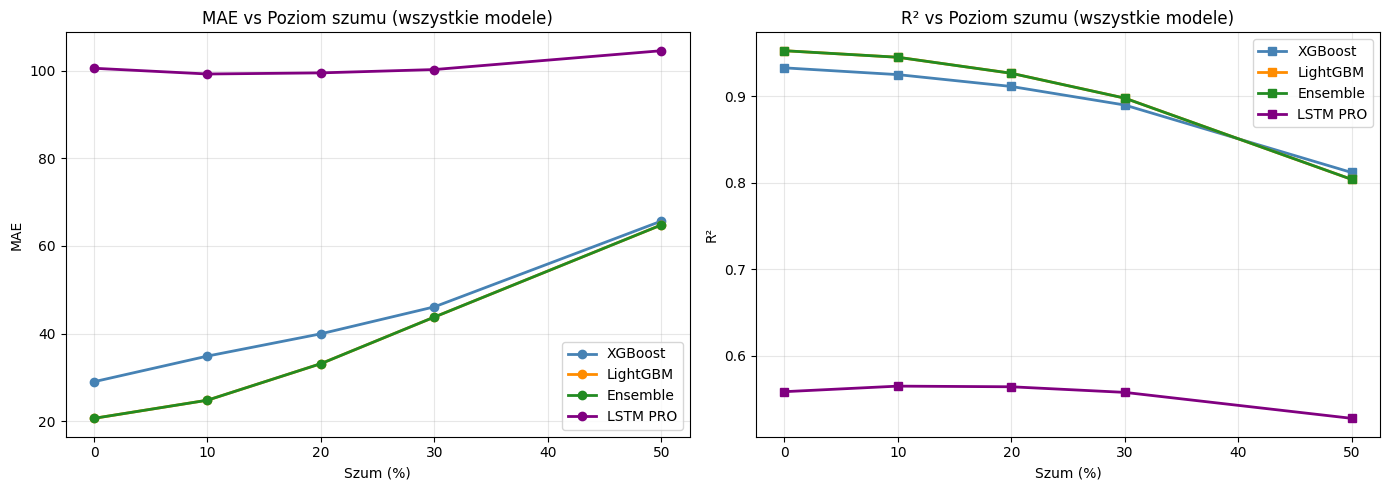


4. RANKING ODPORNOŚCI
   XGBoost: 58.8% Wrażliwy
   LightGBM: 111.8% Wrażliwy
   Ensemble: 111.8% Wrażliwy
   LSTM PRO: -0.3% Odporny

   Najbardziej odporny: LSTM PRO (-0.3%)


In [11]:
def add_gaussian_noise(X, noise_level=0.1, cols=None, seed=42):
    np.random.seed(seed)
    X_noisy = X.copy()
    if cols is None:
        cols = X_noisy.select_dtypes(include=[np.number]).columns
    for col in cols:
        noise = np.random.normal(0, noise_level * X_noisy[col].std(), size=X_noisy.shape[0])
        X_noisy[col] += noise
    return X_noisy

def add_gaussian_noise_lstm(X, noise_level=0.1, seed=42):
    np.random.seed(seed)
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def add_outliers(X, outlier_fraction=0.05, outlier_strength=3.0, cols=None, seed=42):
    np.random.seed(seed)
    X_noisy = X.copy().reset_index(drop=True).astype(float)
    if cols is None:
        cols = X_noisy.select_dtypes(include=[np.number]).columns
    n_outliers = int(outlier_fraction * X_noisy.shape[0])
    outlier_indices = np.random.choice(X_noisy.shape[0], n_outliers, replace=False)
    for col in cols:
        col_std, col_mean = X_noisy[col].std(), X_noisy[col].mean()
        outlier_values = np.random.choice([col_mean + outlier_strength * col_std, col_mean - outlier_strength * col_std], size=n_outliers)
        X_noisy.iloc[outlier_indices, X_noisy.columns.get_loc(col)] = outlier_values
    return X_noisy

print("\n1. TEST SZUMU GAUSSOWSKIEGO (Tree models + LSTM)")
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5]

# Tree-based models
models_tree = {'XGBoost': xgb_model, 'LightGBM': lgb_model, 'Ensemble': best_model}
results_noise = []

for noise_level in noise_levels:
    X_test_noisy = X_test.copy() if noise_level == 0 else add_gaussian_noise(X_test, noise_level=noise_level)
    for model_name, model in models_tree.items():
        y_pred_noisy = model.predict(X_test_noisy)
        results_noise.append({
            'noise_level': noise_level, 'model': model_name,
            'mae': mean_absolute_error(y_test, y_pred_noisy),
            'r2': r2_score(y_test, y_pred_noisy)
        })

# LSTM PRO model
for noise_level in noise_levels:
    X_test_lstm_noisy = X_test_pro.copy() if noise_level == 0 else add_gaussian_noise_lstm(X_test_pro, noise_level=noise_level)
    y_pred_lstm_noisy = lstm_pro_model.predict(X_test_lstm_noisy, verbose=0)
    y_pred_lstm_noisy_inv = scaler_y_pro.inverse_transform(y_pred_lstm_noisy)
    results_noise.append({
        'noise_level': noise_level, 'model': 'LSTM PRO',
        'mae': mean_absolute_error(y_test_pro_original, y_pred_lstm_noisy_inv),
        'r2': r2_score(y_test_pro_original, y_pred_lstm_noisy_inv)
    })

results_noise_df = pd.DataFrame(results_noise)

print("\n2. TEST OUTLIERS")
X_test_outliers = add_outliers(X_test, outlier_fraction=0.05, outlier_strength=3.0)
print("   Tree-based models:")
for model_name, model in models_tree.items():
    y_pred_out = model.predict(X_test_outliers)
    print(f"     {model_name}: MAE={mean_absolute_error(y_test, y_pred_out):.2f}, R²={r2_score(y_test, y_pred_out):.4f}")

X_test_lstm_outliers = add_gaussian_noise_lstm(X_test_pro, noise_level=0.15)
y_pred_lstm_out = lstm_pro_model.predict(X_test_lstm_outliers, verbose=0)
y_pred_lstm_out_inv = scaler_y_pro.inverse_transform(y_pred_lstm_out)
print(f"     LSTM PRO: MAE={mean_absolute_error(y_test_pro_original, y_pred_lstm_out_inv):.2f}, R²={r2_score(y_test_pro_original, y_pred_lstm_out_inv):.4f}")

print("\n3. WIZUALIZACJA")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_models = {'XGBoost': 'steelblue', 'LightGBM': 'darkorange', 'Ensemble': 'forestgreen', 'LSTM PRO': 'purple'}
for model in ['XGBoost', 'LightGBM', 'Ensemble', 'LSTM PRO']:
    model_data = results_noise_df[results_noise_df['model'] == model]
    axes[0].plot(model_data['noise_level'] * 100, model_data['mae'], marker='o', linewidth=2, label=model, color=colors_models[model])
axes[0].set_xlabel('Szum (%)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs Poziom szumu (wszystkie modele)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for model in ['XGBoost', 'LightGBM', 'Ensemble', 'LSTM PRO']:
    model_data = results_noise_df[results_noise_df['model'] == model]
    axes[1].plot(model_data['noise_level'] * 100, model_data['r2'], marker='s', linewidth=2, label=model, color=colors_models[model])
axes[1].set_xlabel('Szum (%)')
axes[1].set_ylabel('R²')
axes[1].set_title('R² vs Poziom szumu (wszystkie modele)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('robustness_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n4. RANKING ODPORNOŚCI")
# Oblicz degradację dla każdego modelu przy 30% szumu
robustness_results = []
for model in ['XGBoost', 'LightGBM', 'Ensemble', 'LSTM PRO']:
    baseline = results_noise_df[(results_noise_df['noise_level'] == 0) & (results_noise_df['model'] == model)]['mae'].iloc[0]
    noisy = results_noise_df[(results_noise_df['noise_level'] == 0.3) & (results_noise_df['model'] == model)]['mae'].iloc[0]
    degradation = ((noisy - baseline) / baseline * 100)
    robustness_results.append({'Model': model, 'Degradacja (%)': degradation})
    status = 'Odporny' if degradation < 25 else 'Średni' if degradation < 50 else 'Wrażliwy'
    print(f"   {model}: {degradation:.1f}% {status}")

best_robust = min(robustness_results, key=lambda x: x['Degradacja (%)'])
print(f"\n   Najbardziej odporny: {best_robust['Model']} ({best_robust['Degradacja (%)']:.1f}%)")

### Symulacja Dynamic Pricing

**Cel:** Zasymulować wpływ dynamicznego ustalania cen na przychody w oparciu o prognozowanie popytu.

**Strategia:** Dostosowywanie cen w zależności od przewidywanego popytu:
- Wysoki popyt → wyższa cena (maksymalizacja marży)
- Niski popyt → niższa cena (stymulacja sprzedaży)

**Elastyczność cenowa:** Zmiana ceny o X% powoduje zmianę popytu o -E×X% (gdzie E = elastyczność)

**Model dynamiczny z trzema efektami:**
1. **Nasycenie rynku (Pantry Loading)** - jeśli klienci kupią więcej dziś, popyt jutro spada (zanik 30%/dzień)
2. **Akwizycja klientów** - niższa cena przyciąga nowych klientów, którzy wracają (bonus do przyszłego popytu)
3. **Asymetryczna elastyczność** - klienci słabiej reagują na podwyżki niż na obniżki (loss aversion odwrócone dla marki)

In [23]:
np.random.seed(42)

PRICE_ELASTICITY = 0.6
MIN_PRICE_CHANGE = -0.10
MAX_PRICE_CHANGE = 0.25
SATURATION_DECAY = 0.7
SATURATION_IMPACT = 0.25
CUSTOMER_ACQUISITION_RATE = 0.02
ACQUISITION_DECAY = 0.85
ASYMMETRIC_ELASTICITY_FACTOR = 0.6

def calculate_dynamic_price(base_price, predicted_demand, avg_demand, strategy='percentile'):
    if strategy == 'percentile':
        demand_ratio = predicted_demand / avg_demand if avg_demand > 0 else 1
        if demand_ratio > 1.3:
            price_change = 0.18
        elif demand_ratio > 1.15:
            price_change = 0.10
        elif demand_ratio > 1.0:
            price_change = 0.04
        elif demand_ratio < 0.7:
            price_change = -0.08
        elif demand_ratio < 0.9:
            price_change = -0.03
        else:
            price_change = 0
    else:
        price_change = np.clip((predicted_demand / avg_demand - 1) * 0.3, MIN_PRICE_CHANGE, MAX_PRICE_CHANGE)
    
    return base_price * (1 + price_change), price_change

def adjust_demand_for_price(original_demand, price_change_pct, elasticity=PRICE_ELASTICITY):
    if price_change_pct > 0:
        effective_elasticity = elasticity * ASYMMETRIC_ELASTICITY_FACTOR
    else:
        effective_elasticity = elasticity
    demand_change = -effective_elasticity * price_change_pct
    return max(0, original_demand * (1 + demand_change))

top_products = df_all_agg.groupby('product_id')['sales'].sum().nlargest(3).index.tolist()
simulation_results = []
for product in top_products:
    product_data = df_all_agg[df_all_agg['product_id'] == product].copy().sort_values('date')
    
    if len(product_data) < 30:
        continue
    
    test_start = int(len(product_data) * 0.8)
    test_data = product_data.iloc[test_start:].copy()
    
    if len(test_data) < 10:
        continue
    
    avg_demand = product_data['sales'].mean()
    avg_price = product_data['price'].mean()
    
    static_revenue = 0
    dynamic_revenue = 0
    static_units = 0
    dynamic_units = 0
    
    inventory_saturation = 0
    customer_base_bonus = 0
    
    daily_results = []
    
    for idx, row in test_data.iterrows():
        actual_demand = row['sales']
        base_price = row['price']
        
        effective_base_demand = actual_demand * (1 - inventory_saturation * SATURATION_IMPACT + customer_base_bonus)
        effective_base_demand = max(0.1, effective_base_demand)
        
        noise_factor = np.random.uniform(0.9, 1.1)
        predicted_demand = effective_base_demand * noise_factor
        
        static_revenue += actual_demand * base_price
        static_units += actual_demand
        
        new_price, price_change = calculate_dynamic_price(base_price, predicted_demand, avg_demand)
        adjusted_demand = adjust_demand_for_price(effective_base_demand, price_change)
        
        excess_demand_ratio = (adjusted_demand - actual_demand) / actual_demand if actual_demand > 0 else 0
        inventory_saturation = inventory_saturation * SATURATION_DECAY + max(0, excess_demand_ratio)
        
        if price_change < 0:
            customer_base_bonus = customer_base_bonus * ACQUISITION_DECAY + abs(price_change) * CUSTOMER_ACQUISITION_RATE
        else:
            customer_base_bonus = customer_base_bonus * ACQUISITION_DECAY
        
        dynamic_revenue += adjusted_demand * new_price
        dynamic_units += adjusted_demand
        
        daily_results.append({
            'date': row['date'],
            'actual_demand': actual_demand,
            'effective_demand': effective_base_demand,
            'predicted_demand': predicted_demand,
            'base_price': base_price,
            'dynamic_price': new_price,
            'price_change_pct': price_change * 100,
            'adjusted_demand': adjusted_demand,
            'saturation': inventory_saturation,
            'customer_bonus': customer_base_bonus,
            'static_revenue': actual_demand * base_price,
            'dynamic_revenue': adjusted_demand * new_price
        })
    
    revenue_gain = dynamic_revenue - static_revenue
    revenue_gain_pct = (revenue_gain / static_revenue) * 100 if static_revenue > 0 else 0
    
    simulation_results.append({
        'product': product,
        'static_revenue': static_revenue,
        'dynamic_revenue': dynamic_revenue,
        'revenue_gain': revenue_gain,
        'revenue_gain_pct': revenue_gain_pct,
        'static_units': static_units,
        'dynamic_units': dynamic_units,
        'daily_data': pd.DataFrame(daily_results)
    })

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'daily_data'} 
                           for r in simulation_results])
results_df = results_df.sort_values('revenue_gain_pct', ascending=False)

print("SYMULACJA DYNAMIC PRICING (z efektem nasycenia rynku)")
print("=" * 60)
total_static = results_df['static_revenue'].sum()
total_dynamic = results_df['dynamic_revenue'].sum()
total_gain = total_dynamic - total_static
total_gain_pct = (total_gain / total_static) * 100

print(f"Przychód bez dynamic pricing: ${total_static:,.2f}")
print(f"Przychód z dynamic pricing: ${total_dynamic:,.2f}")
print(f"Wzrost przychodu: ${total_gain:,.2f} ({total_gain_pct:+.2f}%)\n")
print(results_df[['product', 'static_revenue', 'dynamic_revenue', 'revenue_gain_pct']].to_string(index=False))

SYMULACJA DYNAMIC PRICING (z efektem nasycenia rynku)
Przychód bez dynamic pricing: $818,939.20
Przychód z dynamic pricing: $830,220.49
Wzrost przychodu: $11,281.29 (+1.38%)

product  static_revenue  dynamic_revenue  revenue_gain_pct
  P0438    32910.199409     35299.305848          7.259471
  P0103   703059.100000    711846.560236          1.249889
  P0364    82969.899277     83074.619798          0.126215


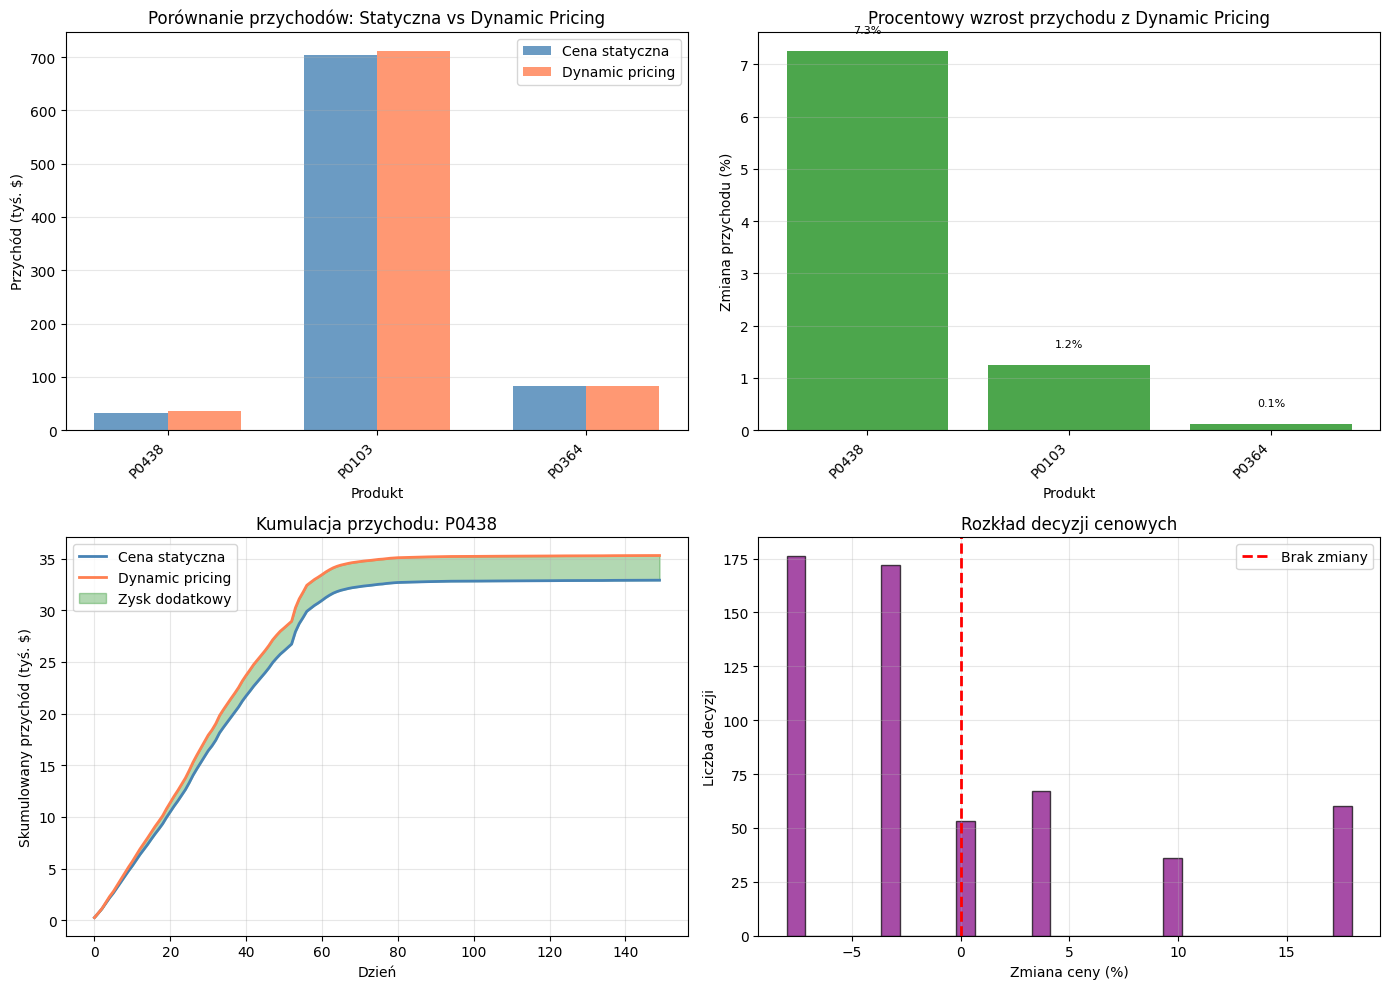

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
top_n = min(10, len(results_df))
products_plot = results_df['product'].head(top_n).values
static_rev = results_df['static_revenue'].head(top_n).values
dynamic_rev = results_df['dynamic_revenue'].head(top_n).values

x = np.arange(len(products_plot))
width = 0.35

bars1 = ax1.bar(x - width/2, static_rev/1000, width, label='Cena statyczna', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, dynamic_rev/1000, width, label='Dynamic pricing', color='coral', alpha=0.8)
ax1.set_xlabel('Produkt')
ax1.set_ylabel('Przychód (tyś. $)')
ax1.set_title('Porównanie przychodów: Statyczna vs Dynamic Pricing')
ax1.set_xticks(x)
ax1.set_xticklabels([p[:15] for p in products_plot], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
gains = results_df['revenue_gain_pct'].head(top_n).values
colors = ['green' if g > 0 else 'red' for g in gains]
bars = ax2.bar(products_plot, gains, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Produkt')
ax2.set_ylabel('Zmiana przychodu (%)')
ax2.set_title('Procentowy wzrost przychodu z Dynamic Pricing')
ax2.set_xticklabels([p[:15] for p in products_plot], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, gains):
    ypos = bar.get_height() + 0.3 if bar.get_height() > 0 else bar.get_height() - 0.8
    ax2.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.1f}%', ha='center', va='bottom' if val > 0 else 'top', fontsize=8)

ax3 = axes[1, 0]
best_product_idx = results_df['revenue_gain_pct'].idxmax()
best_product = results_df.loc[best_product_idx, 'product']
best_daily = [r['daily_data'] for r in simulation_results if r['product'] == best_product][0]

ax3.plot(range(len(best_daily)), best_daily['static_revenue'].cumsum()/1000, 
         label='Cena statyczna', linewidth=2, color='steelblue')
ax3.plot(range(len(best_daily)), best_daily['dynamic_revenue'].cumsum()/1000, 
         label='Dynamic pricing', linewidth=2, color='coral')
ax3.fill_between(range(len(best_daily)), 
                  best_daily['static_revenue'].cumsum()/1000,
                  best_daily['dynamic_revenue'].cumsum()/1000,
                  alpha=0.3, color='green', label='Zysk dodatkowy')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Skumulowany przychód (tyś. $)')
ax3.set_title(f'Kumulacja przychodu: {best_product[:30]}')
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
price_changes = np.concatenate([r['daily_data']['price_change_pct'].values for r in simulation_results])
ax4.hist(price_changes, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Brak zmiany')
ax4.set_xlabel('Zmiana ceny (%)')
ax4.set_ylabel('Liczba decyzji')
ax4.set_title('Rozkład decyzji cenowych')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dynamic_pricing_simulation.png', dpi=150, bbox_inches='tight')
plt.show()